# Проверка гипотезы: можно ли перейти с `user_course` на уровень `user`

В ноутбуке проверяем две вещи:

1. Сколько курсов в среднем приходится на одного пользователя.
2. Возвращаются ли пользователи, отчисленные в модуле 1, в модули 2-4 в другие курсы.

Логика:

- берём только `stats__module_1.csv` ... `stats__module_4.csv`;
- считаем число уникальных `course_id` на пользователя;
- отдельно смотрим распределение по каждому модулю и по всем четырём модулям вместе;
- затем проверяем пересечение пользователей из `Статус = Отчислен` в модуле 1 с модулями 2, 3 и 4.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="talk")

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "modules":
    candidate = NOTEBOOK_DIR / "hackathon" / "modules"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

DATA_DIR = NOTEBOOK_DIR.parent / "src"
MODULE_FILES = {
    1: DATA_DIR / "stats__module_1.csv",
    2: DATA_DIR / "stats__module_2.csv",
    3: DATA_DIR / "stats__module_3.csv",
    4: DATA_DIR / "stats__module_4.csv",
}

print(f"Папка ноутбука: {NOTEBOOK_DIR}")
print(f"Папка с данными: {DATA_DIR}")
print("Все файлы найдены:", all(path.exists() for path in MODULE_FILES.values()))

Папка ноутбука: /Users/maria/Desktop/uni/hackathon/modules
Папка с данными: /Users/maria/Desktop/uni/hackathon/src
Все файлы найдены: True


## Загрузка и подготовка данных

Для анализа достаточно трёх полей: `user_id`, `course_id` и `Статус`.

Перед расчётами делаем две технические вещи:

- убираем строки без `user_id` или `course_id`;
- внутри каждого модуля оставляем уникальные пары `user_id` + `course_id`.

Это важно, потому что в модуле 1 есть повторные строки одного и того же пользователя на одном и том же курсе.

In [14]:
def load_module(module_number: int) -> pd.DataFrame:
    df = pd.read_csv(MODULE_FILES[module_number])
    df = df.copy()
    df["module"] = module_number
    return df


raw_modules = {module: load_module(module) for module in MODULE_FILES}

quality_rows = []
prepared_modules = {}

for module, df in raw_modules.items():
    valid_mask = df["user_id"].notna() & df["course_id"].notna()
    valid = df.loc[valid_mask].copy()

    dedup_cols = ["user_id", "course_id"]
    if "Статус" in valid.columns:
        prepared = valid[["user_id", "course_id", "Статус", "module"]].drop_duplicates(subset=dedup_cols)
    else:
        prepared = valid[["user_id", "course_id", "module"]].drop_duplicates(subset=dedup_cols)

    prepared_modules[module] = prepared
    duplicate_rows = len(valid) - len(valid.drop_duplicates(subset=dedup_cols))

    quality_rows.append(
        {
            "module": module,
            "raw_rows": len(df),
            "rows_without_user_or_course": int((~valid_mask).sum()),
            "rows_after_filter": len(valid),
            "duplicate_user_course_rows": duplicate_rows,
            "unique_users": valid["user_id"].nunique(),
            "unique_user_course_pairs": len(prepared),
        }
    )

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

,module,raw_rows,rows_without_user_or_course,rows_after_filter,duplicate_user_course_rows,unique_users,unique_user_course_pairs
0,1,3261,61,3200,228,2972,2972
1,2,1955,0,1955,0,1955,1955
2,3,1785,0,1785,0,1785,1785
3,4,1707,18,1689,0,1689,1689


Короткая интерпретация:

- пропуски по `user_id` / `course_id` есть в модулях 1 и 4;
- реальные дубли `user-course` есть только в модуле 1;
- значит, даже перед простым описательным анализом данные лучше считать по уникальным парам `user_id` + `course_id`.

In [15]:
module_1_raw = raw_modules[1].copy()
module_1_valid = module_1_raw[module_1_raw["user_id"].notna() & module_1_raw["course_id"].notna()].copy()

duplicate_examples = (
    module_1_valid[module_1_valid.duplicated(subset=["user_id", "course_id"], keep=False)]
    .sort_values(["user_id", "course_id", "teacher_id"])
    [["user_id", "course_id", "teacher_id", "id параллели", "Статус"]]
    .head(10)
)

display(duplicate_examples)

,user_id,course_id,teacher_id,id параллели,Статус
130,700083.0,1029.0,718537.0,1190.0,Отчислен
129,700083.0,1029.0,732430.0,1190.0,Отчислен
176,700342.0,1029.0,699986.0,1147.0,Завершил
174,700342.0,1029.0,700313.0,1147.0,Завершил
175,700342.0,1029.0,727409.0,1147.0,Завершил
218,700389.0,1029.0,699986.0,1147.0,Отчислен
216,700389.0,1029.0,700313.0,1147.0,Отчислен
217,700389.0,1029.0,727409.0,1147.0,Отчислен
111,700449.0,1029.0,699986.0,1147.0,Завершил
109,700449.0,1029.0,700313.0,1147.0,Завершил


Пример выше показывает, что в модуле 1 один и тот же `user-course` может повторяться с разными `teacher_id`. Это не новый курс, а техническое дублирование записи.

## Распределение числа курсов на пользователя

Сначала считаем количество уникальных `course_id` на пользователя:

- отдельно в каждом модуле;
- затем по всем четырём модулям сразу.

Если внутри одного модуля почти у всех пользователей ровно один курс, то внутри модуля можно думать на уровне `user`. Но если объединять модули, один пользователь естественно накапливает несколько `course_id`, потому что у разных модулей разные курсы.

In [16]:
all_prepared = pd.concat(prepared_modules.values(), ignore_index=True)


def build_user_course_distribution(df: pd.DataFrame) -> pd.DataFrame:
    distribution = (
        df.groupby("user_id")["course_id"]
        .nunique()
        .rename("n_courses")
        .reset_index()
    )
    return distribution


distribution_all = build_user_course_distribution(all_prepared)
distribution_by_module = {
    module: build_user_course_distribution(df)
    for module, df in prepared_modules.items()
}

summary_rows = []

for module, dist in distribution_by_module.items():
    summary_rows.append(
        {
            "scope": f"module_{module}",
            "users": len(dist),
            "mean_courses_per_user": round(dist["n_courses"].mean(), 4),
            "median_courses_per_user": round(dist["n_courses"].median(), 4),
            "max_courses_per_user": int(dist["n_courses"].max()),
            "share_users_with_more_than_1_course": round((dist["n_courses"] > 1).mean(), 4),
        }
    )

summary_rows.append(
    {
        "scope": "all_modules",
        "users": len(distribution_all),
        "mean_courses_per_user": round(distribution_all["n_courses"].mean(), 4),
        "median_courses_per_user": round(distribution_all["n_courses"].median(), 4),
        "max_courses_per_user": int(distribution_all["n_courses"].max()),
        "share_users_with_more_than_1_course": round((distribution_all["n_courses"] > 1).mean(), 4),
    }
)

distribution_summary = pd.DataFrame(summary_rows)
display(distribution_summary)

,scope,users,mean_courses_per_user,median_courses_per_user,max_courses_per_user,share_users_with_more_than_1_course
0,module_1,2972,1.0000,1.0,1,0.0000
1,module_2,1955,1.0000,1.0,1,0.0000
2,module_3,1785,1.0000,1.0,1,0.0000
3,module_4,1689,1.0000,1.0,1,0.0000
4,all_modules,2972,2.8267,4.0,4,0.6578


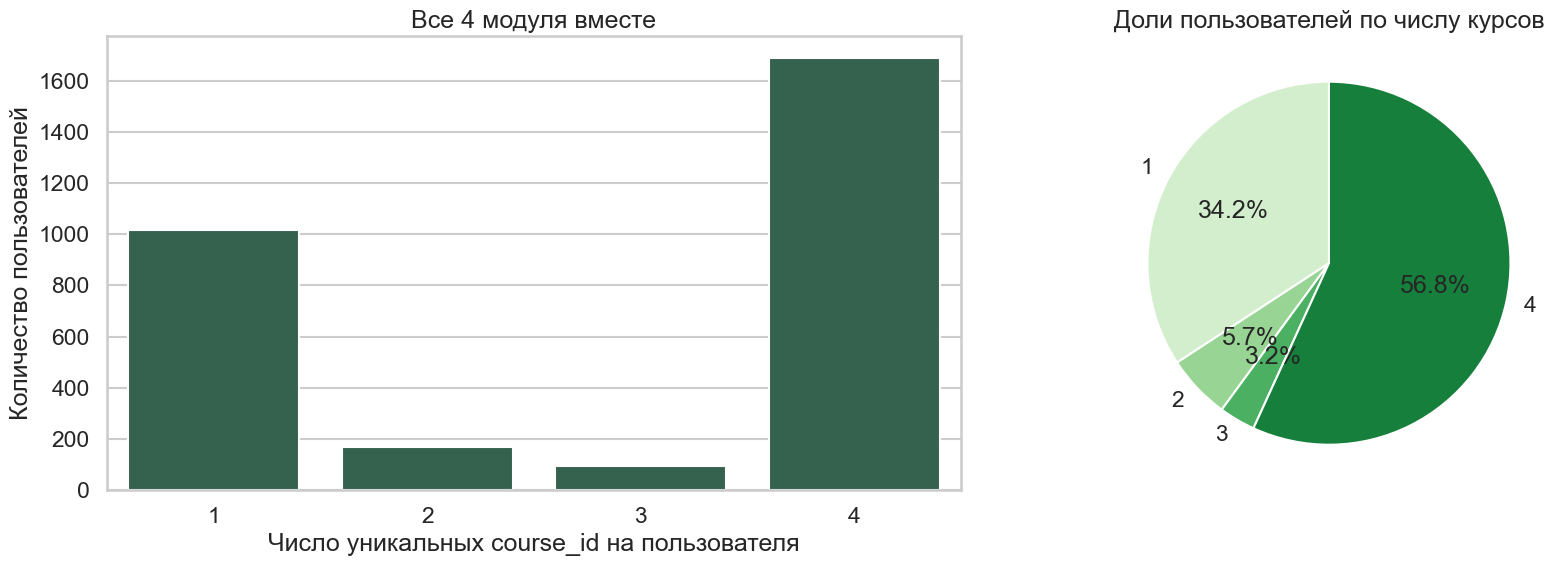

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(
    data=distribution_all,
    x="n_courses",
    color="#2D6A4F",
    ax=axes[0],
)
axes[0].set_title("Все 4 модуля вместе")
axes[0].set_xlabel("Число уникальных course_id на пользователя")
axes[0].set_ylabel("Количество пользователей")

all_counts = distribution_all["n_courses"].value_counts().sort_index()
axes[1].pie(
    all_counts.values,
    labels=all_counts.index.astype(str),
    autopct="%.1f%%",
    startangle=90,
    colors=sns.color_palette("Greens", n_colors=len(all_counts)),
)
axes[1].set_title("Доли пользователей по числу курсов")

plt.tight_layout()
plt.show()

Что показывают таблица и графики:

- внутри каждого отдельного модуля среднее число курсов на пользователя равно `1.0`, медиана тоже `1.0`, а доля пользователей с более чем одним курсом равна `0%`;
- если объединить все 4 модуля, среднее число курсов на пользователя уже равно `2.8267`, медиана равна `4`, а доля пользователей более чем с одним курсом составляет `65.78%`;
- это означает, что внутри одного модуля запись почти всегда можно свести к уровню `user`, но при анализе всей траектории по 4 модулям пользователь уже связан с несколькими курсами;
- причина не в шуме данных, а в самой структуре программы: разные модули оформлены как разные курсы, поэтому один и тот же `user_id` закономерно встречается с разными `course_id`.

## Возвращаются ли отчисленные из модуля 1 в модули 2-4

Теперь проверяем вторую гипотезу.

Берём всех пользователей со статусом `Отчислен` в модуле 1 и ищем их по `user_id` в модулях 2, 3 и 4.

Если пересечения есть, тогда дополнительно сравниваем `course_id`: это тот же курс или другой.

In [18]:
def check_returns(source_module: int, next_modules: list[int]) -> pd.DataFrame:
    source = prepared_modules[source_module].copy()
    expelled = source.loc[source["Статус"] == "Отчислен", ["user_id", "course_id"]].drop_duplicates()

    rows = []
    for target_module in next_modules:
        target = prepared_modules[target_module][["user_id", "course_id"]].drop_duplicates()
        returned = expelled.merge(
            target,
            on="user_id",
            how="inner",
            suffixes=(f"_module_{source_module}", f"_module_{target_module}"),
        )

        rows.append(
            {
                "source_module": source_module,
                "target_module": target_module,
                "expelled_users": expelled["user_id"].nunique(),
                "returned_users": returned["user_id"].nunique(),
                "returned_rows": len(returned),
                "same_course_id": int((returned[f"course_id_module_{source_module}"] == returned[f"course_id_module_{target_module}"]).sum()) if len(returned) else 0,
                "different_course_id": int((returned[f"course_id_module_{source_module}"] != returned[f"course_id_module_{target_module}"]).sum()) if len(returned) else 0,
            }
        )

    return pd.DataFrame(rows)


In [19]:
returns_from_module_1 = check_returns(source_module=1, next_modules=[2, 3, 4])
display(returns_from_module_1)

,source_module,target_module,expelled_users,returned_users,returned_rows,same_course_id,different_course_id
0,1,2,1017,0,0,0,0
1,1,3,1017,0,0,0,0
2,1,4,1017,0,0,0,0


По факту здесь нули по всем трём переходам.

Это означает, что из `1017` пользователей, отчисленных в модуле 1, ни один не появляется дальше ни в модуле 2, ни в модуле 3, ни в модуле 4. В пределах этих сводных таблиц сценарий «отчислился в модуле 1, а потом вернулся позже на другой курс» не наблюдается.

## Возвращаются ли отчисленные из модуля 2 в модули 3-4

Теперь делаем ту же проверку для модуля 2: берём пользователей со статусом `Отчислен` и ищем их в модулях 3 и 4.

In [20]:
returns_from_module_2 = check_returns(source_module=2, next_modules=[3, 4])
display(returns_from_module_2)

,source_module,target_module,expelled_users,returned_users,returned_rows,same_course_id,different_course_id
0,2,3,170,0,0,0,0
1,2,4,170,0,0,0,0


Здесь картина такая же: из `170` пользователей, отчисленных в модуле 2, никто не появляется в модулях 3 и 4. Значит, и на этом шаге траектория выглядит линейной: отчисление в модуле 2 обрывает движение по следующим модулям.

## Возвращаются ли отчисленные из модуля 3 в модуль 4

Для модуля 3 нужна отдельная оговорка: в `stats__module_3.csv` нет колонки `Статус`. Значит, проверку можно сделать только если сначала определить список отчисленных по внешнему правилу.

В текущем ноутбуке используем простой рабочий признак: считаем пользователя отчисленным, если хотя бы один из обязательных критериев не выполнен.

In [21]:
module_3 = raw_modules[3].copy()
module_3 = module_3[module_3["user_id"].notna() & module_3["course_id"].notna()].copy()
module_3 = module_3.drop_duplicates(subset=["user_id", "course_id"])

module_3["heuristic_status"] = "Завершил"
module_3.loc[
    (module_3["Посетил урок в онлайне"] != "Да")
    | (module_3["Просмотрено 720ед видеоконт и 80% ур "] != "Да")
    | (module_3["Решены все обяз.ИЗ"] != "Да")
    | (module_3["Пройден тек.контроль"] != "Да")
    | (module_3["Пройдена рефлексия"] != "Да")
    | (module_3["Сдал ПА"] != "Да"),
    "heuristic_status",
] = "Отчислен"

expelled_from_module_3 = module_3.loc[module_3["heuristic_status"] == "Отчислен", ["user_id", "course_id"]].drop_duplicates()
module_4_users = prepared_modules[4][["user_id", "course_id"]].drop_duplicates()

returns_from_module_3 = expelled_from_module_3.merge(
    module_4_users,
    on="user_id",
    how="inner",
    suffixes=("_module_3", "_module_4"),
)

returns_from_module_3_summary = pd.DataFrame([
    {
        "source_module": 3,
        "target_module": 4,
        "expelled_users": expelled_from_module_3["user_id"].nunique(),
        "returned_users": returns_from_module_3["user_id"].nunique(),
        "returned_rows": len(returns_from_module_3),
        "same_course_id": int((returns_from_module_3["course_id_module_3"] == returns_from_module_3["course_id_module_4"]).sum()) if len(returns_from_module_3) else 0,
        "different_course_id": int((returns_from_module_3["course_id_module_3"] != returns_from_module_3["course_id_module_4"]).sum()) if len(returns_from_module_3) else 0,
    }
])

display(returns_from_module_3_summary)

,source_module,target_module,expelled_users,returned_users,returned_rows,same_course_id,different_course_id
0,3,4,385,291,291,0,291


Здесь важно ограничение интерпретации.

- В модуле 3 нет фактической колонки `Статус`, поэтому список «отчисленных» построен по эвристике (по бизнес-логике из документации).
- По этой эвристике в модуле 3 получается `385` пользователей со статусом `Отчислен`.
- Из них `291` появляются в модуле 4.

Поэтому этот результат нельзя трактовать как реальное возвращение именно отчисленных студентов. Корректная трактовка такая: если пометить часть студентов модуля 3 как `Отчислен` по текущему правилу, то значимая часть этих студентов всё равно присутствует в модуле 4. Это сильный сигнал, что эвристика для модуля 3 не эквивалентна фактическому таргету и не должна использоваться как доказательство отчисления.

## Та же проверка для модуля 3 по более простой эвристике

Теперь считаем статус в модуле 3 ещё проще:

- если `Сдал ПА == Да`, считаем, что пользователь `Завершил` модуль;
- иначе считаем его `Отчислен`.

После этого снова проверяем, появляются ли такие «отчисленные» пользователи в модуле 4.

In [22]:
module_3_pa = raw_modules[3].copy()
module_3_pa = module_3_pa[module_3_pa["user_id"].notna() & module_3_pa["course_id"].notna()].copy()
module_3_pa = module_3_pa.drop_duplicates(subset=["user_id", "course_id"])

module_3_pa["heuristic_status_pa_only"] = "Отчислен"
module_3_pa.loc[module_3_pa["Сдал ПА"] == "Да", "heuristic_status_pa_only"] = "Завершил"

expelled_from_module_3_pa = module_3_pa.loc[
    module_3_pa["heuristic_status_pa_only"] == "Отчислен",
    ["user_id", "course_id"],
].drop_duplicates()

returns_from_module_3_pa = expelled_from_module_3_pa.merge(
    module_4_users,
    on="user_id",
    how="inner",
    suffixes=("_module_3", "_module_4"),
)

returns_from_module_3_pa_summary = pd.DataFrame([
    {
        "source_module": 3,
        "target_module": 4,
        "expelled_users": expelled_from_module_3_pa["user_id"].nunique(),
        "returned_users": returns_from_module_3_pa["user_id"].nunique(),
        "returned_rows": len(returns_from_module_3_pa),
        "same_course_id": int((returns_from_module_3_pa["course_id_module_3"] == returns_from_module_3_pa["course_id_module_4"]).sum()) if len(returns_from_module_3_pa) else 0,
        "different_course_id": int((returns_from_module_3_pa["course_id_module_3"] != returns_from_module_3_pa["course_id_module_4"]).sum()) if len(returns_from_module_3_pa) else 0,
    }
])

display(returns_from_module_3_pa_summary)

,source_module,target_module,expelled_users,returned_users,returned_rows,same_course_id,different_course_id
0,3,4,78,0,0,0,0


Здесь результат уже другой.

- По эвристике `Сдал ПА == Да -> Завершил`, иначе `Отчислен`, в модуле 3 получается `78` отчисленных пользователей.
- Из этих `78` пользователей никто не появляется в модуле 4.

То есть эта более узкая эвристика ведёт себя намного ближе к ожидаемой траектории: если студент не сдал ПА в модуле 3, дальше в модуле 4 он уже не встречается. Для практической интерпретации это правило выглядит заметно устойчивее, чем предыдущая составная эвристика.

## Уникальны ли `course_id` по разным модулям

Теперь отдельно проверяем, можно ли по одному только `course_id` понять, к какому модулю относится запись.

Для этого:

- выпишем уникальные `course_id` по каждому модулю;
- посчитаем попарные пересечения между модулями.

Если пересечений нет, значит `course_id` уникален на уровне модулей в этих сводных таблицах.

In [23]:
course_ids_by_module = {
    module: sorted(df["course_id"].dropna().unique().tolist())
    for module, df in raw_modules.items()
}

course_ids_df = pd.DataFrame(
    {
        "module": list(course_ids_by_module.keys()),
        "course_ids": [", ".join(str(int(course_id)) for course_id in course_ids) for course_ids in course_ids_by_module.values()],
        "n_unique_course_id": [len(course_ids) for course_ids in course_ids_by_module.values()],
    }
)

display(course_ids_df)

,module,course_ids,n_unique_course_id
0,1,"1029, 1030",2
1,2,"951, 954",2
2,3,"952, 955",2
3,4,"953, 956",2


In [24]:
intersection_matrix = pd.DataFrame(index=sorted(course_ids_by_module), columns=sorted(course_ids_by_module), dtype=int)

for left_module in sorted(course_ids_by_module):
    left_set = set(course_ids_by_module[left_module])
    for right_module in sorted(course_ids_by_module):
        right_set = set(course_ids_by_module[right_module])
        intersection_matrix.loc[left_module, right_module] = len(left_set & right_set)

intersection_matrix.index.name = "module"
display(intersection_matrix)

,1,2,3,4
module,,,,
1,2.0,0.0,0.0,0.0
2,0.0,2.0,0.0,0.0
3,0.0,0.0,2.0,0.0
4,0.0,0.0,0.0,2.0


Вывод здесь однозначный: множества `course_id` по модулям не пересекаются.

- модуль 1: `1029`, `1030`;
- модуль 2: `951`, `954`;
- модуль 3: `952`, `955`;
- модуль 4: `953`, `956`.

Значит, в рамках этих сводных таблиц `course_id` фактически кодирует номер модуля. Это ещё один аргумент против полного перехода на уровень `user`: если убрать `course_id`, мы одновременно теряем и информацию о самом курсе, и информацию о том, на каком этапе обучения находится пользователь.

## Итог

### 1. Главный содержательный вывод

Для анализа всех четырёх модулей вместе базовой единицей наблюдения нужно оставлять **`user-course`**, а не просто `user`.

### 2. Что мы увидели в данных

После очистки и дедупликации получаем такую картину:

- модуль 1: `2972` уникальные пары `user_id + course_id`;
- модуль 2: `1955`;
- модуль 3: `1785`;
- модуль 4: `1689`.

Внутри каждого отдельного модуля один пользователь соответствует одному курсу.

Но если объединить все четыре модуля в одну выборку, картина меняется:

- среднее число курсов на пользователя = `2.8267`;
- медиана = `4`;
- `65.78%` пользователей имеют более одного курса;
- максимум на пользователя = `4` курса.

То есть на масштабе всей программы один и тот же `user_id` регулярно встречается несколько раз - пользователь переходит из одного курса в другий, если не отчисляется.

### 3. Почему для всех четырёх модулей уровень `user` уже неверен

Если схлопнуть данные до одного `user_id` сразу по всей траектории, теряется критически важная информация.

1. Смешиваются разные этапы обучения.
   Один и тот же пользователь может быть в модуле 1 неуспешным, а в модуле 3 успешным. Если оставить только одну строку на пользователя, эти состояния смешаются.

2. Теряется модульный контекст признаков.
   Просмотры, выполнение задач, контроль, рефлексия и аттестация считаются не «вообще по пользователю», а для конкретного модуля. Без привязки к курсу или модулю такие признаки перестают быть однозначными.

3. `course_id` здесь фактически кодирует модуль.
   Мы отдельно проверили, что множества `course_id` по модулям не пересекаются: `1029/1030` для модуля 1, `951/954` для модуля 2, `952/955` для модуля 3, `953/956` для модуля 4. Значит, удаляя `course_id`, мы теряем и идентификатор курса, и информацию об этапе обучения.

4. Возникает риск неправильной интерпретации признаков и таргета.
   На уровне `user` показатели из более поздних модулей могут неявно «подмешиваться» к более раннему состоянию пользователя. Для аналитики это ведёт к логическим ошибкам, а для моделирования - к потенциальной утечке смысла.

### 4. Что дополнительно подтверждает линейность траектории

Проверка фактических статусов усиливает этот вывод:

- из `1017` пользователей, отчисленных в модуле 1, никто не появляется в модулях 2, 3, 4;
- из `170` пользователей, отчисленных в модуле 2, никто не появляется в модулях 3, 4.

Это показывает, что в доступных сводных таблицах траектория действительно выглядит модульной и последовательной. Для реального отчисления в модулях 1-2 не видно сценария «вернулся позже в другой курс».

Важно отдельно помнить про модуль 3: там нет фактического `Статус`, поэтому эвристическая проверка не должна использоваться как доказательство возврата или невозврата. Однако здесь мы можем оценить качество логики вычисления статуса. По предоставленной бизнес логике Статус вычисляется гораздо хуже, чем по простому правилу "Прошел ПА == Да".
Если вычислять статус по "Прошел ПА == Да", то в модуле 4 нет студентов, отчисленных в модуле 3, что подтверждает правильность этой логики.

### 5. Качество данных

- в модулях 1 и 4 есть строки без `user_id` или `course_id`;
- в модуле 1 есть `228` повторов пары `user_id + course_id` после удаления строк без ID;
- эти строки отличаются только `teacher_id` и лежат в рамках одного course_id.


### Итого
Правильный рабочий уровень - **`user-course`**.